# CRE III - Assignment 1: Parameter Estimation
Benjamin Heuschmid , Sanskar Nashier, Maximilian Franz (Group 2)

## 1 Introduction

Parameter estimation plays an important role in chemical reaction engineering, since reliable kinetic and transport parameters are required for the simulation, optimization, and scale-up of chemical reactors. Accurate reactor models are essential for process development, safety analysis, and the prediction of concentration and temperature profiles under different operating conditions. However, many reaction parameters, such as reaction rate constants and kinetic orders, cannot be measured directly and therefore must be determined by fitting mathematical models to experimentally obtained data.

In heterogeneous and homogeneous reacting systems, experimentally measured concentration profiles provide valuable information about the underlying reaction mechanisms and kinetics. By analyzing these profiles, reaction hypotheses can be developed and validated using numerical simulations and parameter fitting techniques. If the agreement between experimental and simulated data is insufficient, the proposed reaction network and kinetic expressions must be revised until a satisfactory representation of the system behavior is achieved.

In this assignment, experimentally obtained concentration data from an isothermal batch stirred tank reactor are analyzed in order to establish a suitable reaction hypothesis and kinetic model. Different experimental cases with varying initial concentrations are evaluated to identify possible reaction pathways and intermediates. The resulting reaction network is implemented in Python, and the kinetic parameters are estimated by fitting the simulated concentration profiles to the experimental data.

## 2 Experimental Data

In the first step, all required packages are imported and the path to the experimental data is defined.

In [1]:
# Imports of packages
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import ICIW_Plots.colors as iciw_colors
plt.style.use("ICIWstyle")
import scipy.integrate as integ
from lmfit import Model, Minimizer, Parameters, report_fit

# Path to folder with csv-data
path = "2026_Task_data"


The experimental data is extracted from six CSV files and stored in lists: `t_eval` for time points, `exp_concs` for concentration profiles, and `c_inits` for initial concentrations. The concentration data is then flattened into a single array for use in the parameter estimation.

In [ ]:
# create list of files in directory
os_list = os.listdir(path)
# provide length of list, which equals the number of experiments (nex)
nex = len(os_list)

exp_concs = []
t_eval = []
c_inits = []
for i in np.arange(0, nex):
    aux = pd.read_csv(path + r'\Exp_res_' + str(i) + '.csv')
    t_eval.append(aux.values.transpose()[0, :])         
    c_inits.append(aux.values.transpose()[1:, 0])       
    exp_concs.append(aux.values.transpose()[1:, :])     

# Create flattened array of results
nex = len(exp_concs)
exp_concs_flat = np.array([])
for i in np.arange(0, nex):
    exp_concs_flat = np.append(exp_concs_flat, exp_concs[i])

#### Plotting Configuration

To improve readability and consistency, fixed colors are assigned to each component. These colors are used throughout all plots in the notebook. Each experiment is plotted separately to inspect concentration trends, identify reactants and product behavior, and verify data consistency.


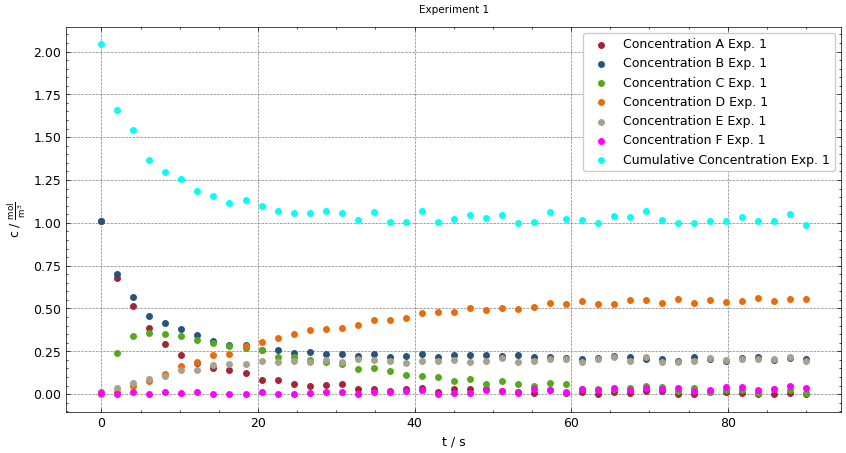

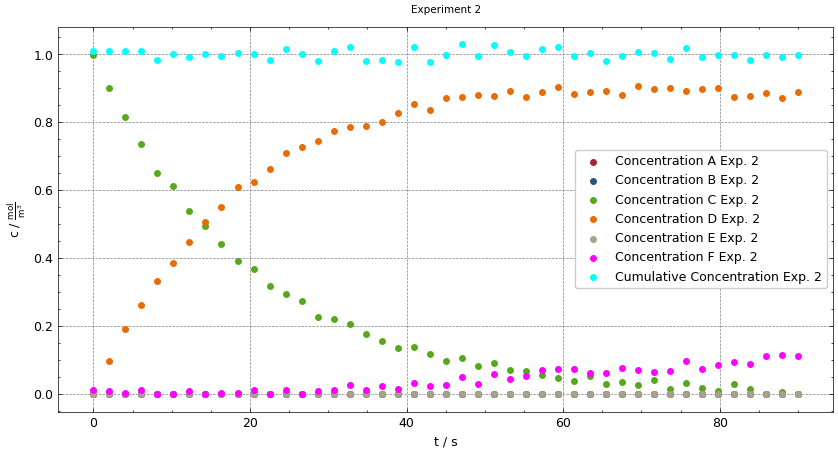

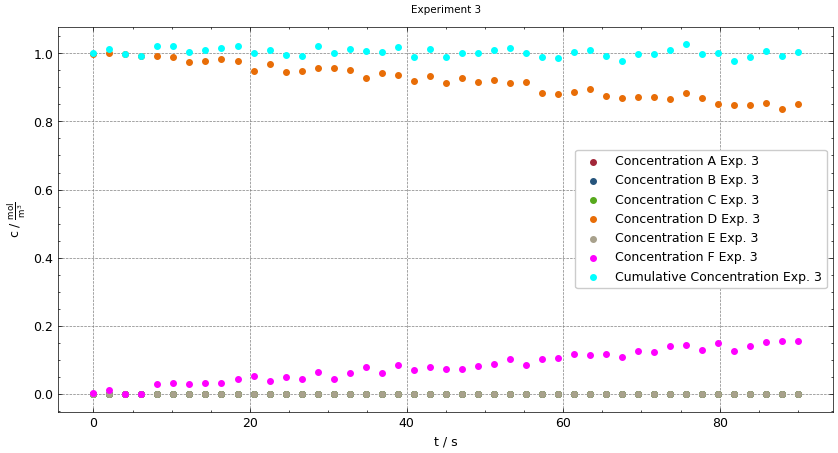

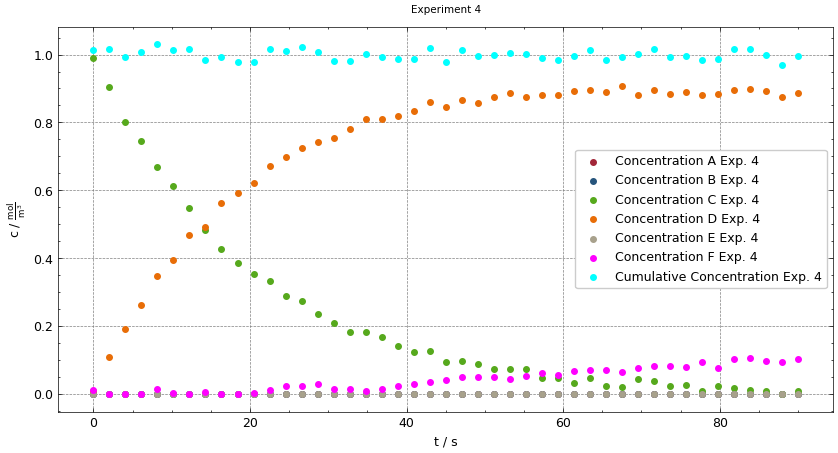

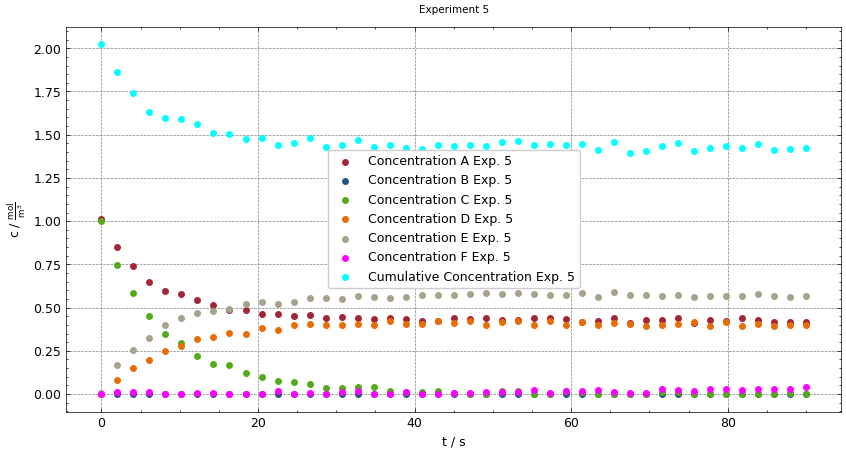

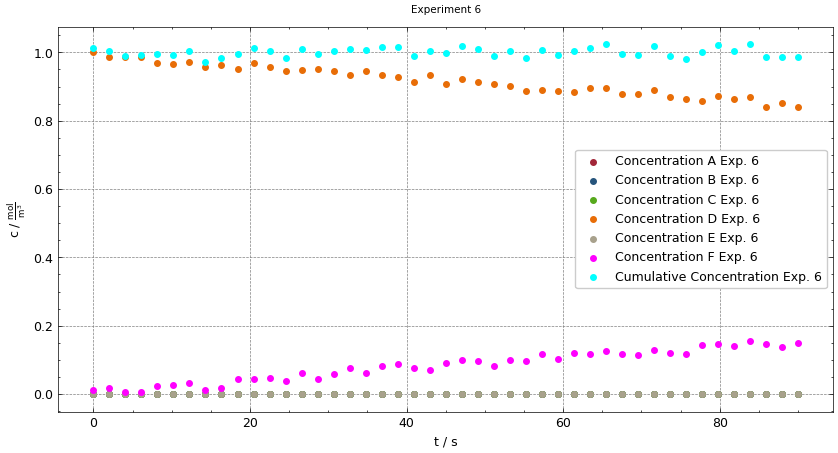

In [ ]:
# Automatic plotting of all experiments

# Define the chemical components
components = ["A", "B", "C", "D", "E", "F"]


# Assign fixed colors to each component
colors = {
    "A": iciw_colors.CRIMSON,
    "B": iciw_colors.CERULEAN,
    "C": iciw_colors.KELLYGREEN,
    "D": iciw_colors.FLAME,
    "E": iciw_colors.DRAB,
    "F": "magenta"
}

# Plotting the concentration profiles over time for each experiment separately

for exp in range(1, nex + 1):

    exp_idx = exp - 1

    fig, ax = plt.subplots(figsize=(10, 5))

    cumulative = 0


    for comp in components:

        comp_idx = components.index(comp)

        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )

        cumulative += exp_concs[exp_idx][comp_idx, :]

    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )

    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.legend()
    ax.set_title(f"Experiment {exp}")
    plt.show()


## 3 Hypothesis
### 3.1 Data Editing

Before the Differential Equation containing the whole reaction network can be set up the data has to be edited.
The experimental measurements contain small noise that can produce slightly negative values, which physically impossible. These are clipped to zero.

For further simplification the inital concentrations are approximated by either 1 or 0. Since the measurement noise can impact these values, or make them negative, any inital concentration above 0.5 is set to 1 and below 0.5 to 0.

Each experiment only involves certain species. Species that are not fed in and cannot be produced (given the reaction network) are forced to zero. This avoids fitting noise in inactive channels and improves solver stability. These species are identified via the plotting of the raw data earlier.
Here the following components are "inert":
- Experiment 2: A, B and E,
- Experiment 3: A, B, C and E
- Experiment 4: A, B and E
- Experiment 5: B
- Experiment 6: A, B, C and E


In [ ]:
# Negative concentration values to zero
for i in range(nex):
    exp_concs[i] = np.clip(exp_concs[i], 0.0, None)
 
# Round initial conditions to binary (0 or 1) 
for i in range(nex):
    c_inits[i] = np.where(c_inits[i] >= 0.5, 1.0, 0.0)
 

# Assigning index for each component
comp_idx = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5
}
 
# Components to zero in each experiment
zero_dict = {
    2: ["A", "B", "E"],
    3: ["A", "B", "C", "E"],
    4: ["A", "B", "E"],
    5: ["B"],
    6: ["A", "B", "C", "E"]
}
 
for exp, comps in zero_dict.items():
 
    exp_idx = exp - 1   
 
    for comp in comps:
 
        row = comp_idx[comp]  
        exp_concs[exp_idx][row, :] = 0.0
        c_inits[exp_idx][row] = 0.0
 
# Re-flatten data after zeroing 
exp_concs_flat = np.array([])
 
for i in range(nex):
    exp_concs_flat = np.append(exp_concs_flat, exp_concs[i])

### 3.2 Reaction network hypothesis

#### Experiment 1 
Experiment 1 contains all components; therefore, no unique reaction pathway can be identified directly from this experiment alone.

Components A and B are present at t=0 and are therefore considered initial reactants. Since the concentration profile of B approaches a plateau at longer reaction times, an equilibrium involving B may exist.

The decrease in concentrations of A and B indicates the formation of at least one intermediate species. Whether A and B react directly with each other or participate in separate reactions cannot be concluded unambiguously from this experiment alone.

Component C most likely acts as an intermediate species, as its concentration reaches a maximum during the early stage of the reaction before decreasing again.

#### Experiment 2 
In Experiment 2, only component C is initially present. 
During the reaction, components D and eventually F are formed.

\begin{equation}
    \nu_\mathrm{C, 2} C \rightarrow \nu_\mathrm{D, 2} D \rightarrow  \nu_\mathrm{F, 2} F \\
\end{equation}

From the cumulative concentration profiles, it follows that all stoichiometric coefficients are equal to 1. The resulting reaction network is therefore:

\begin{equation}
    C \rightarrow D \rightarrow  F \\
\end{equation}

#### Experiment 3 
In Experiment 3, only component D is initially present, and component F is formed over time.

This confirms that the formation of F originates solely from D and does not require the simultaneous presence of C.

Using the stoichiometry derived from the cumulative concentrations, the reaction can be written as:
\begin{equation}
    D \rightarrow  F \\
\end{equation}

#### Experiment 4 
Experiment 4 is comparable to Experiment 2, with the exception that component B is additionally present.

Since the concentration profiles remain unchanged compared to Experiment 2, component B can be considered inert with respect to components C, D, and F.

Furthermore component B is reacting with A.
From experiment 1, where component E is not present at the beginning can be 

#### Experiment 5 
In Experiment 5, components A and C are initially present, leading to the formation of D, E, and F.
From Experiments 2 and 3, the reaction pathway
\begin{equation}
    C \rightarrow D \rightarrow  F \\
\end{equation}
has already been established.

The additional formation of component E suggests a further reaction involving A. Two possible pathways can initially be proposed:

\begin{equation}
    A \rightarrow E \\
\end{equation}
or
\begin{equation}
    A + C \rightarrow E \\
\end{equation}

#### Experiment 6 
In Experiment 6, components A and E remain unchanged, while D continues to react to F.

This observation indicates that the formation of E does not occur in the absence of C. Consequently, the reaction

\begin{equation}
    A \rightarrow E \\
\end{equation}

can be excluded.

Therefore, the formation of E is most likely described by:

\begin{equation}
    A + C \rightarrow E \\
\end{equation}

#### Full reaction network

From the findings of all Experiments the following reaction network can be assertained:

\begin{equation}
    A + B \rightarrow C \\
\end{equation}

\begin{equation}
    A + C \rightarrow E \\
\end{equation}

\begin{equation}
    C \rightarrow D \\
\end{equation}

\begin{equation}
    D \rightarrow F \\
\end{equation}

### 3.3 Differential Equation

After editing the data and setting up the reaction network the Differential Equation can be set up.
Here the assumption is established, that every component has the reaction order 1 and the stoichiometry of 1.

In [ ]:
def ode(t, c, k):
    """
    Input:
    t: float
        time of the calculation/experiments, size [nt]
    c: array
        concentration values at time t, size [nc]
        c[0] = c_A; c[1] = c_B; c[2] = c_C; c[3] = c_D; c[4] = c_E; c[5] = c_F
    k: array
        kinetic coefficients for all reactions, size [nr]
    Output:
    dcdt: array
        derivatives of the concentration over time, size [nc]
    """
    dcdt = np.zeros_like(c)
 
    # Calculate reaction rates
    r0 = k[0] * c[0] * c[1]     # A + B -> C 
    r1 = k[1] * c[0] * c[2]     # A + C -> E 
    r2 = k[2] * c[2]            # C -> D     
    r3 = k[3] * c[3]            # D -> F     
 
    # Mass balances
    dcdt[0] = - r0 - r1         # dA/dt
    dcdt[1] = - r0              # dB/dt
    dcdt[2] = + r0 - r1 - r2    # dC/dt
    dcdt[3] = + r2 - r3         # dD/dt
    dcdt[4] = + r1              # dE/dt
    dcdt[5] = + r3              # dF/dt
    return dcdt

The `sim_exp` function solves the functions of the `ode` to simulate an actual experiment.
The `sim_multiple_exps` function simulates multiple experiments and returns the concentration profiles for each experiment.
The `residual` function lets lmfit compare the simulation with the experimental data. The `residual` function is minimized during parameter fitting.


In [ ]:
# Single Experiment Simulation
def sim_exp(t, c_init, k):
    """
    Input:
    t: array
       array with the time points of the simulation, size [nt]
    c_init: array
        initial concentrations, size [nc]
    k: array
        kinetic coefficients for every reaction, size [nr]
    Output:
    c_sol: array
        concentration values at time t, size [nc, nt]
    """
   # Define the time span from first to last time point
    t_sp = np.array([t[0], t[-1]])
 
    # Numerically integrate the ODE system
    sol = integ.solve_ivp(
        fun=ode,          
        t_span=t_sp,      
        y0=c_init,        
        method='LSODA',   
        t_eval=t,         
        args=[k]          
    )
    c_sol = sol.y   
    return c_sol

# Multi-Experiment Simulation
def sim_multiple_exps(times, k0, k1, k2, k3, c_inits):
    """
    Input:
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    k0: float
        Kinetic parameter of first reaction
    k1: float
        Kinetic parameter of second reaction
    k2: float
        Kinetic parameter of third reaction
    k3: float
        Kinetic parameter of fourth reaction
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    Output:
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]   
 
    nex = len(times)
    for i in np.arange(0, nex):
        c_0 = c_inits[i]   
        t   = times[i]     
        conc = sim_exp(t, c_0, k)   
        sim_concs.append(conc)
    return sim_concs

# Residual function for parameter estimation
def residual(params, times, c_inits, data):
    """
    Input:
    params: Parameters
        Parameter object containing all variables (here only the kinetic constant) to be estimated
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    data: list
        List of arrays with concentration values from experiment, size[n][nc, nt_i].
    Output:
    concs_flat - data: array
        flattened array of differences between simulation and experimental data, size[n*nc*nt_i]
    """
    
    sim_conc = sim_multiple_exps(
        times,
        params["k0"],
        params["k1"],
        params["k2"],
        params["k3"],
        c_inits
    )
 
    # Flatten simulated results 
    nex = len(times)
    concs_flat = np.array([])
    for i in np.arange(0, nex):
        concs_flat = np.append(concs_flat, sim_conc[i])
    return concs_flat - data

Parameter Estimation and Minimizer
In the next step, the parameters k0, k1 and k2 are estimated and adjusted to best fit the simulation to the experimental data.
In the last step, the best-fit parameters are used to simulate the concentration profile based on the hypothesized reaction network.

In [ ]:
# Define the parameters
params = Parameters()
params.add('k0', value=0.5, min=0, max=10, vary=True)   # A + B -> C
params.add('k1', value=0.5, min=0, max=10, vary=True)   # A + C -> E
params.add('k2', value=0.5, min=0, max=10, vary=True)   # C -> D
params.add('k3', value=0.5, min=0, max=10, vary=True)   # D -> F
 
# Set up the minimizer 
minner = Minimizer(
    residual,           
    params,             
    fcn_args=(          
        t_eval,
        c_inits,
        exp_concs_flat
    )
)
 
result = minner.minimize()
report_fit(result)


model = Model(sim_multiple_exps, independent_vars=['times', 'c_inits'])
best_fit = sim_multiple_exps(
    times=t_eval,
    k0=result.params['k0'],
    k1=result.params['k1'],
    k2=result.params['k2'],
    k3=result.params['k3'],
    c_inits=c_inits
)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 52
    # data points      = 1620
    # variables        = 4
    chi-square         = 0.12094217
    reduced chi-square = 7.4840e-05
    Akaike info crit   = -15386.2513
    Bayesian info crit = -15364.6906
[[Variables]]
    k0:  0.20257775 +/- 0.00129686 (0.64%) (init = 0.5)
    k1:  0.09843743 +/- 3.8703e-04 (0.39%) (init = 0.5)
    k2:  0.05053079 +/- 1.2732e-04 (0.25%) (init = 0.5)
    k3:  0.00171088 +/- 1.0860e-05 (0.63%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.4472
    C(k0, k1) = +0.2827


Plotting results
The simulated concentration profiles are then plotted alongside the experimental data for comparison.

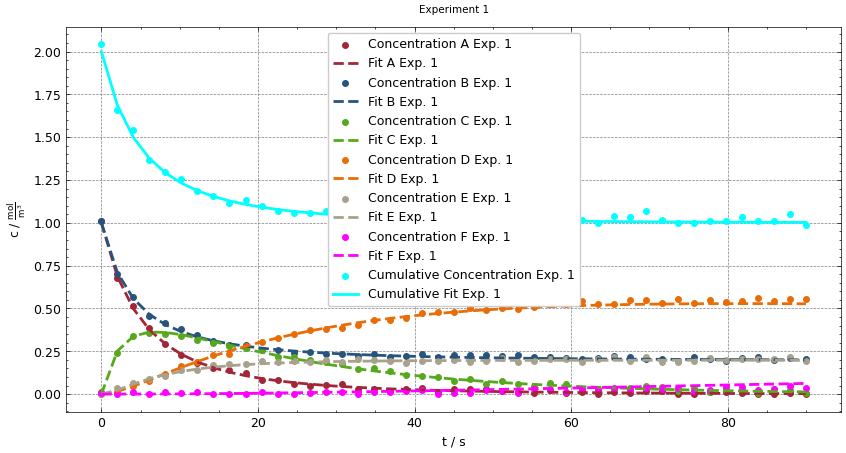

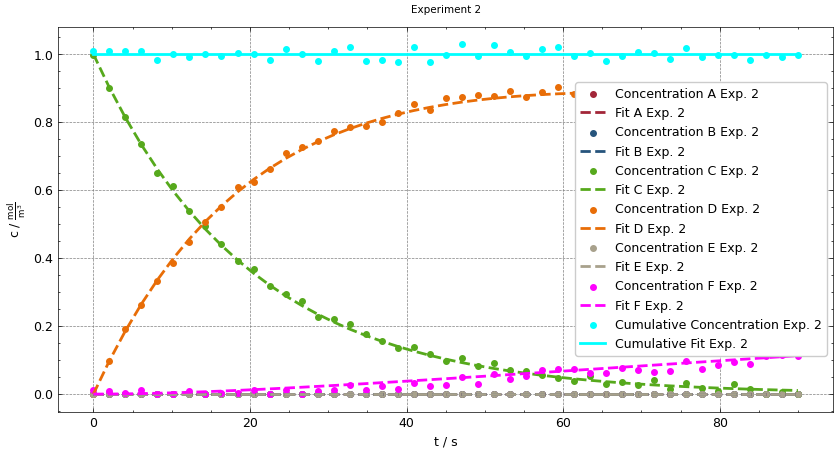

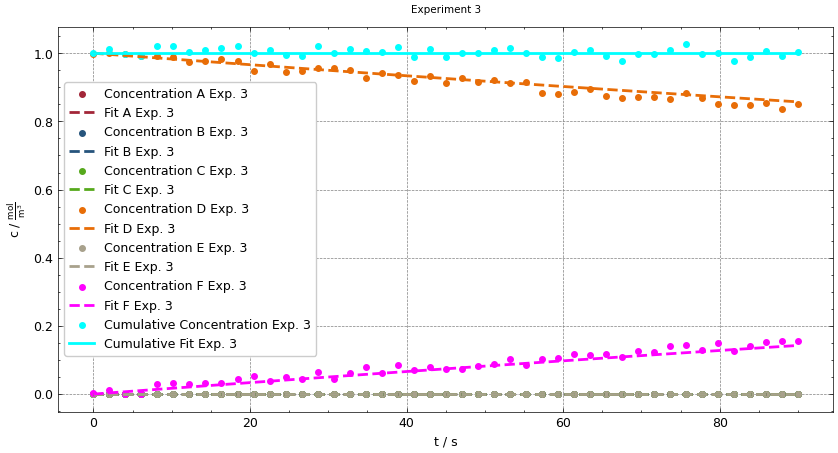

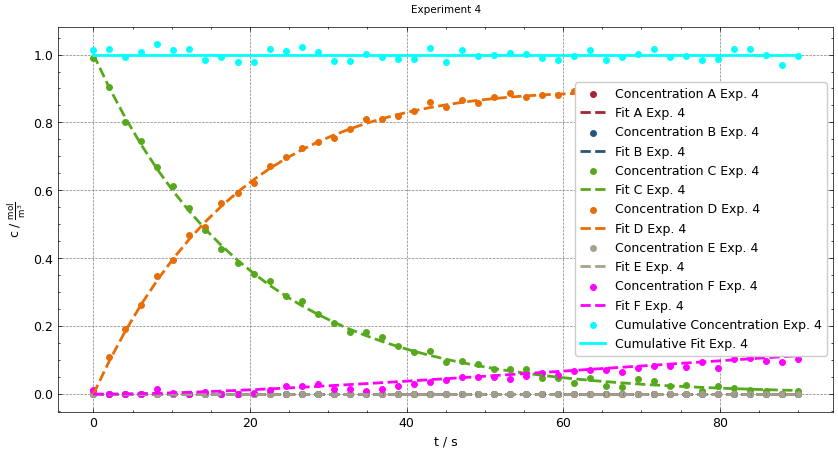

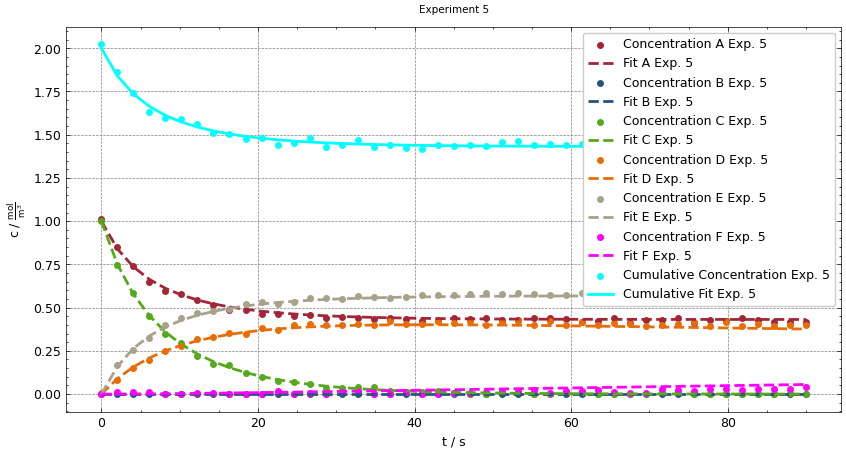

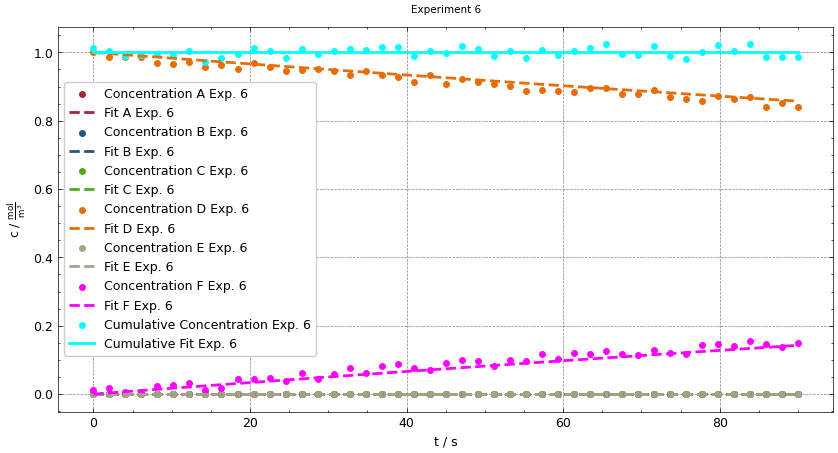

In [ ]:
# Plot each experiment: dots = measured data, dashed lines = model fit
for exp in range(1, nex + 1):
 
    exp_idx = exp - 1           
    fig, ax = plt.subplots(figsize=(10, 5))
    cumulative     = 0          
    cumulative_fit = 0          
    fit_exp = best_fit[exp - 1] 
 
    for comp in components:
        comp_idx_val = components.index(comp)
 
        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx_val, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )

        ax.plot(
            t_eval[exp_idx],
            fit_exp[comp_idx_val, :],
            label=f"Fit {comp} Exp. {exp}",
            color=colors[comp],
            linewidth=2,
            linestyle="--"
        )

        cumulative     += exp_concs[exp_idx][comp_idx_val, :]
        cumulative_fit += fit_exp[comp_idx_val, :]
 
    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )
    
    ax.plot(
        t_eval[exp_idx],
        cumulative_fit,
        label=f"Cumulative Fit Exp. {exp}",
        color="cyan",
        linewidth=2
    )
 
    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.set_title(f"Experiment {exp}")
    ax.legend()
    plt.show()

## 4. Reevalutaion

From the plots above the reaction network is validated.
To further enhance the accuracity the measurement noise is weighted.
Additional the reaction of
\begin{equation}
    D \rightarrow F
\end{equation}
is set to reaction order 2.

To remove confusion and possible errors from running code cells above again every function is defined new with _ro (for reaction order) as a suffix.

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 1620
    # variables        = 4
    chi-square         = 80.5798721
    reduced chi-square = 0.04986378
    Akaike info crit   = -4853.51071
    Bayesian info crit = -4831.94998
[[Variables]]
    k0:  0.19918549 +/- 0.00116064 (0.58%) (init = 0.5)
    k1:  0.10008736 +/- 3.8714e-04 (0.39%) (init = 0.5)
    k2:  0.05000353 +/- 1.1473e-04 (0.23%) (init = 0.5)
    k3:  0.00202089 +/- 1.1400e-05 (0.56%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.3548
    C(k0, k1) = +0.2916


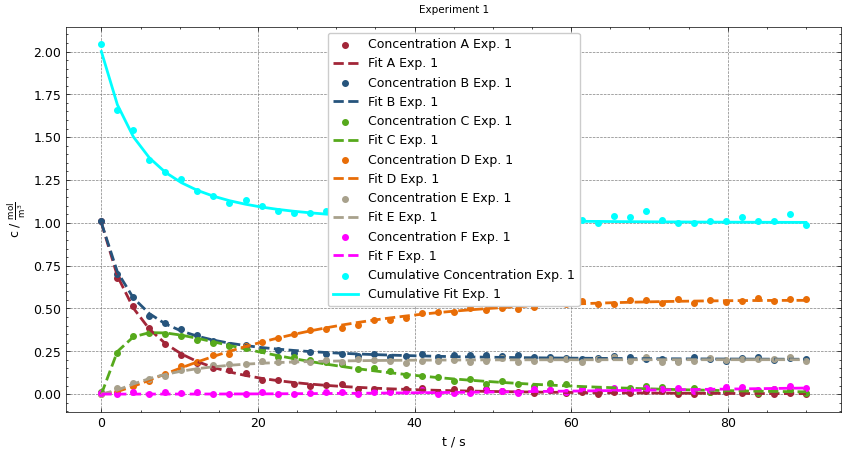

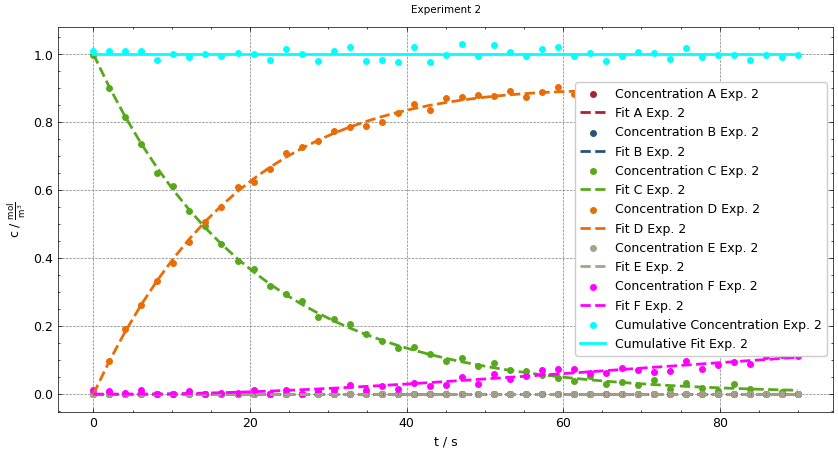

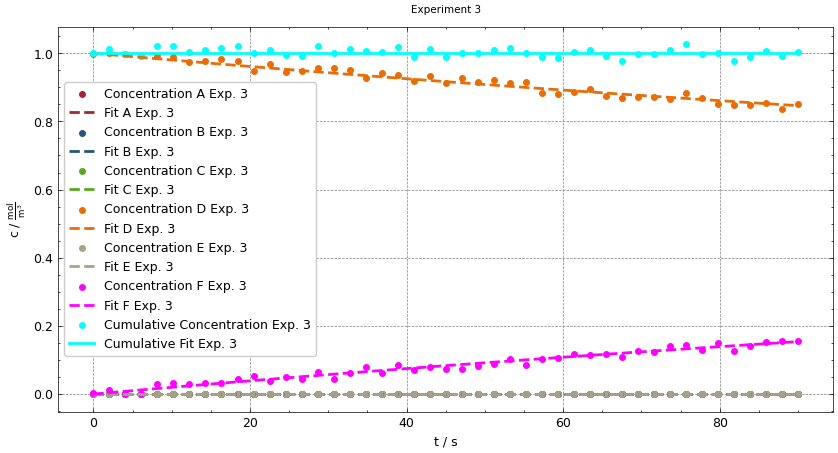

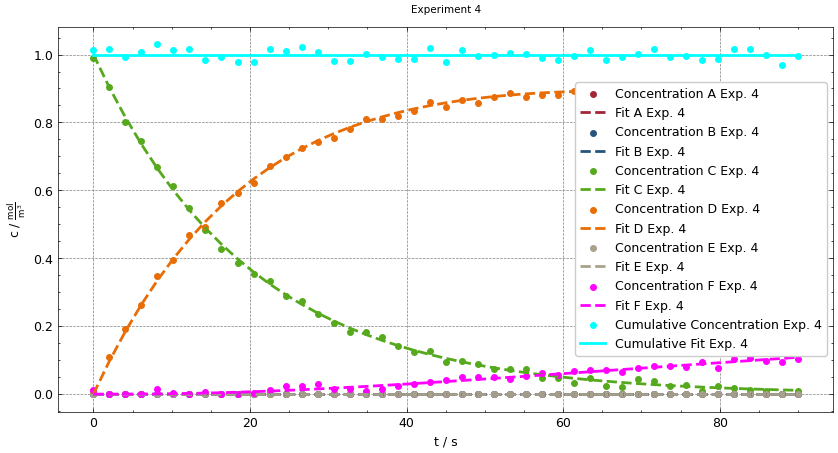

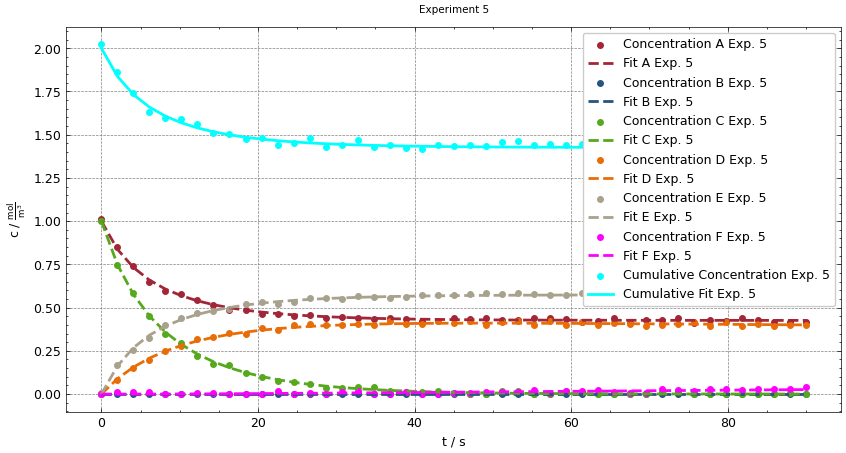

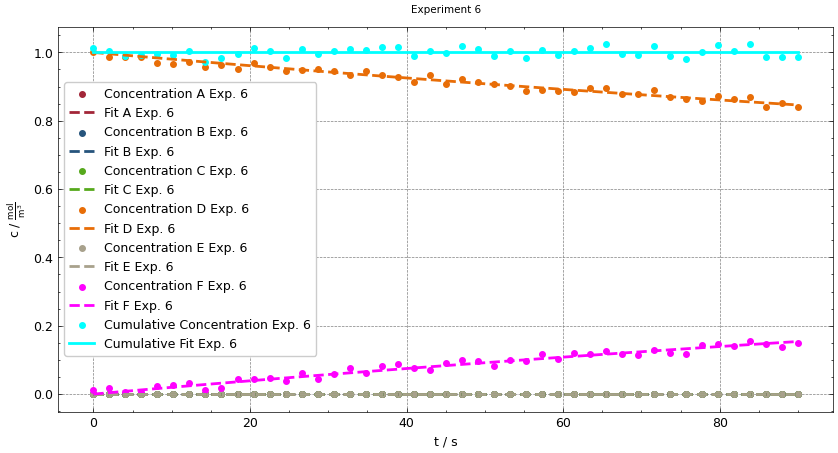

In [15]:
def ode_ro(t, c, k):
    """
    Input:
    t: float
        time of the calculation/experiments, size [nt]
    c: array
        concentration values at time t, size [nc]
        c[0] = c_A; c[1] = c_B; c[2] = c_C; c[3] = c_D; c[4] = c_E; c[5] = c_F
    k: array
        kinetic coefficients for all reactions, size [nr]
    Output:
    dcdt: array
        derivatives of the concentration over time, size [nc]
    """
    dcdt = np.zeros_like(c)

    # calculating the rates for each reaction
    r0 = k[0] * c[0] * c[1]                 # reaction 1: A + B -> C 
    r1 = k[1] * c[0] * c[2]                 # reaction 2: A + C -> E 
    r2 = k[2] * c[2]                        # reaction 3:     C -> D 
    r3 = k[3] * np.power(c[3], 2)           # reaction 4:     D -> F

    # calculating the derivatives for each component
    dcdt[0] = - r0 - r1
    dcdt[1] = - r0
    dcdt[2] = + r0 - r1 - r2
    dcdt[3] = + r2 - r3
    dcdt[4] = + r1
    dcdt[5] = + r3
    return dcdt

def sim_exp_ro(t, c_init, k):
    """
    Input:
    t: array
       array with the time points of the simulation, size [nt]
    c_init: array
        initial concentrations, size [nc]
    k: array
        kinetic coefficients for every reaction, size [nr]
    Output:
    c_sol: array
        concentration values at time t, size [nc, nt]
    """
    t_sp = np.array([t[0], t[-1]])
    sol = integ.solve_ivp(fun=ode_ro, t_span=t_sp, y0=c_init, method='LSODA', t_eval=t, args=[k])
    c_sol = sol.y
    return c_sol

def sim_multiple_exps_ro(times, k0, k1, k2, k3, c_inits):
    """
    Input:
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    k0: float
        Kinetic parameter of first reaction
    k1: float
        Kinetic parameter of second reaction
    k2: float
        Kinetic parameter of third reaction
    k3: float
        Kinetic parameter of fourth reaction
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    Output:
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = sim_exp_ro(t, c_0, k)
        sim_concs.append(conc)
    return sim_concs

def residual(params, times, c_inits, data):
    """
    Input:
    params: Parameters
        Parameter object containing all variables (here only the kinetic constant) to be estimated
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    data: list
        List of arrays with concentration values from experiment, size[n][nc, nt_i].
    Output:
    concs_flat - data: array
        flattened array of differences between simulation and experimental data, size[n*nc*nt_i]
    """
    # number of experiments from length
    sim_conc = sim_multiple_exps_ro(
        times, 
        params["k0"], 
        params["k1"], 
        params["k2"], 
        params["k3"], 
        c_inits)

    nex = len(times)
    concs_flat = np.array([])
    for i in np.arange(0, nex):
        concs_flat = np.append(concs_flat, sim_conc[i])

    # weighting
    sigma = 0.02 + 0.05 * np.abs(data)
    
    return (concs_flat - data) / sigma

params = Parameters()
params.add('k0', value=0.5, min=0, max=10, vary=True)
params.add('k1', value=0.5, min=0, max=10, vary=True)
params.add('k2', value=0.5, min=0, max=10, vary=True)
params.add('k3', value=0.5, min=0, max=10, vary=True)

minner = Minimizer(residual, 
                   params, 
                   fcn_args=(t_eval, 
                             c_inits, 
                             exp_concs_flat))
result = minner.minimize()
report_fit(result)


model_ro = Model(sim_multiple_exps_ro, independent_vars=['times', 'c_inits'])
# initial_fit = model.eval(params, times=t_eval, c_inits=c_inits)
best_fit_ro = sim_multiple_exps_ro(times=t_eval, k0=result.params['k0'], k1=result.params['k1'], k2=result.params['k2'], k3=result.params['k3'], c_inits=c_inits)

for exp in range(1, nex + 1):

    exp_idx = exp - 1
    fig, ax = plt.subplots(figsize=(10,5))
    cumulative = 0
    cumulative_fit = 0
    fit_exp = best_fit_ro[exp - 1]


    for comp in components:
        comp_idx = components.index(comp)
        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )

        ax.plot(
            t_eval[exp_idx],
            fit_exp[comp_idx, :],
            label=f"Fit {comp} Exp. {exp}",
            color=colors[comp],
            linewidth=2,
            linestyle="--"
        )


        cumulative += exp_concs[exp_idx][comp_idx, :]
        cumulative_fit += fit_exp[comp_idx, :]

    # Plot cumulative concentration
    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )

    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.legend()
    ax.set_title(f"Experiment {exp}")

    # cumulative fitted curve
    ax.plot(
        t_eval[exp_idx],
        cumulative_fit,
        label=f"Cumulative Fit Exp. {exp}",
        color="cyan",
        linewidth=2
    )

    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.set_title(f"Experiment {exp}")
    ax.legend()
    plt.show()

## 5. Discussion

Following reaction kinetics have been observed:

k1:  0.19918549 +/- 0.00116064 (0.58%)\
k2:  0.10008736 +/- 3.8714e-04 (0.39%)\
k3:  0.05000353 +/- 1.1473e-04 (0.23%)\
k4:  0.00202089 +/- 1.1400e-05 (0.56%)

The production of C has the highest rate constant. Since B is only consumed by this reaction and A is consumed by reaction 1 and 2, reaction 1 terimates once A has been depleted. By that an equilibrium reaction can be ruled out.

The introduction of a higher reaction order in reaction 4 leads to a better fit compared to different reaction orders.

The fitted ODE model shows good agreement with the experimental concentration profiles across all six experiments, indicating that the proposed reaction network describes the system behavior reasonably well. Reaction 1 with the largest rate constant proceeds most rapidly, while reaction 4 with the smallest reaction rate causes component F to accumulate much later in the progress of the whole reaction. The results also demonstrate that the actual reaction rate depends not only on the kinetic constant but also on reactant concentrations. Remaining deviations originate from measurement noise and the assumption of ideal isothermal operation.

## 6. Conclusion

In this assignment, experimental concentration data from an isothermal batch reactor were analyzed to identify a reaction network and estimate kinetic parameters. A system of ordinary differential equations was developed and fitted to the experimental data using nonlinear least-squares optimization. The resulting model successfully reproduced the main concentration trends observed in all experiments. Although the fit quality was satisfactory, the model still assumes ideal kinetics and constant temperature. Future improvements could include estimating reaction orders, incorporating Arrhenius temperature dependence, and adding energy balances for non-isothermal reactor behavior.

## References

[1] R. Güttel, T. Turek, *Chemische Reaktionstechnik*, Berlin, Heidelberg: Springer Berlin Heidelberg, 2021.

[2] Virtanen, P. et al., *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*, Nature Methods, 2020.
https://doi.org/10.1038/s41592-019-0686-2

[3] Masoud Soroush, *State and parameter estimations and their applications in process control, Computers & Chemical Engineering*, Volume 23, Issue 2, 1998.
https://doi.org/10.1016/S0098-1354(98)00263-4.

[4] Wei-Youh Kuu, James McShane, Joseph Wong, *Determination of mass transfer coefficients during freeze drying using modeling and parameter estimation techniques*, International Journal of Pharmaceutics, Volume
124, Issue 2, 1995, Pages 241-252, ISSN 0378-5173, https://doi.org/10.1016/0378-5173(95)00094-Y.

[5] Newville, M. et al., *LMFIT: Non-Linear Least-Square Minimization and Curve-Fitting for Python*.
https://doi.org/10.5281/zenodo.11813

## AI Use

**1. Tools used**

Claude Sonnet 4.6 (Anthropic), May 2026\
ChatGPT, May 2026\
GitHub Copilot in VS Code, May 2026

**2. Areas of use**

| Subtask | AI |
|---|---|
| Code debugging | Yes |
| Code generation | Yes |
| Concept explanation | Yes |
| Language editing of report | Yes |
| Text generation | No |
| Logic | No |

**3. Prompting strategy**

A usual promt has the following structure:
1) Current state. This might include current code, an error message or a description of a certain task.
2) Own Idea. This might include possible functions to use, a certain logic to follow or may be skipped in case of an error message.
3) Task. What the AI should do.

**4. Critical examination**

All AI outputs are always read carefully and not copied blindly.
Any output that is not explcitly asked for is not used.


**5. Statement of own contribution**

The analysis of each experiment to identify the reaction network, the verification of the reaction hypothesis against the experimental data, and the scientific interpretation of the fitted kinetic constants are group's independent work. The AI was used as a coding and explanation tool and all conclusions in this report were formulated by the group.





## Author Contributions                           
The group members contributed to the work equally.